In [19]:

import numpy as np
from torchvision.datasets import CocoDetection
import datetime
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import sys 
sys.path.append("/home/tyfei/cyroem")
import utils
import importlib 
importlib.reload(utils)
import pycocotools.coco
import random
import pycocotools.mask
import pickle
from scipy.sparse import coo_matrix
from scipy.sparse import csr_matrix
import copy 

In [ ]:
# mix_labels = {
#     "TS_023": "/data/transformer_project/transforemer_model/train_data/20230328_TS_023/amira/results/merged_labels", 
#     "TS_005": "/data/transformer_project/transforemer_model/train_data/20230328_TS_005/amira/results/merged_labels", 
#     "TS_031": "/data/transformer_project/transforemer_model/train_data/TS_031/amira/results/merged_labels", 
#     "sllt0039": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/amira/results/merged_labels_slices", 
#     "sllt0051": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0051/amira/results/merged_labels_slices", 
#     "sllt0081": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/amira/results/merged_labels_slices", 
# }
inteporlate = True
mix_labels = {
    "TS_023": "/data/transformer_project/transforemer_model/train_data/20230328_TS_023/amira/TS_023.mrc_10.30Apx.labels/", 
    "TS_005": "/data/transformer_project/transforemer_model/train_data/20230328_TS_005/amira/TS_005.mrc_10.30Apx.labels/", 
    "TS_031": "/data/transformer_project/transforemer_model/train_data/TS_031/amira/TS_031.mrc_10.30Apx.labels/", 
    "sllt0039": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/amira/sllt0039_9.62Apx.labels/", 
    "sllt0051": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0051/amira/sllt0051_9.62Apx.labels/", 
    "sllt0081": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/amira/sllt0081_9.62Apx.labels/", 
}

ribo = {
    "TS_023": "/data/transformer_project/transforemer_model/train_data/20230328_TS_023/ribo/TS_023.mrc.mrc", 
    "TS_005": "/data/transformer_project/transforemer_model/train_data/20230328_TS_005/ribo/TS_005.mrc.mrc", 
    "TS_031": "/data/transformer_project/transforemer_model/train_data/TS_031/ribo/TS_031.mrc.mrc", 
    "sllt0039": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/ribo/sllt0039.mrc", 
    "sllt0051": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0051/ribo/sllt0051.mrc", 
    "sllt0081": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/ribo/sllt0081.mrc", 
}

membrane = {
    "TS_023": "/data/transformer_project/transforemer_model/train_data/20230328_TS_023/memb/TS_023.mrc_10.30Apx_MemBrain_seg_v10_alpha.ckpt_segmented(5).label-filtering.mrc", 
    "TS_005": "/data/transformer_project/transforemer_model/train_data/20230328_TS_005/memb/TS_005.mrc_10.30Apx_MemBrain_seg_v10_alpha.ckpt_segmented(3).Regions.mrc", 
    "TS_031": "/data/transformer_project/transforemer_model/train_data/TS_031/memb/output_test.to-labelfield-8_bits.eroded.mrc", 
    "sllt0039": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/memb/sllt0039_9.62Apx_MemBrain_seg_v9b.ckpt_segmented.label-filtering.mrc", 
    "sllt0051": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0051/memb/sllt0051_9.62Apx_MemBrain_seg_v9b.ckpt_segmented.label-filtering.mrc", 
    "sllt0081": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/memb/sllt0081_9.62Apx_MemBrain_seg_v9b.ckpt_segmented.label-filtering.mrc", 
}

tomo = {
    "TS_023": "/data/transformer_project/transforemer_model/train_data/20230328_TS_023/tomo/TS_023.mrc_10.30Apx.mrc", 
    "TS_005": "/data/transformer_project/transforemer_model/train_data/20230328_TS_005/tomo/TS_005.mrc_10.30Apx.mrc", 
    "TS_031": "/data/transformer_project/transforemer_model/train_data/TS_031/tomo/TS_031.mrc_10.30Apx.mrc", 
    "sllt0039": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/tomo/sllt0039_9.62Apx.mrc", 
    "sllt0051": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0051/tomo/sllt0051_9.62Apx.mrc", 
    "sllt0081": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/tomo/sllt0081_9.62Apx.mrc", 
}


In [13]:
tomo = {
    "24092001": "/data/transformer_project/transforemer_model/test_data/dxd20240920_mito_nuclear_area/dxd20240920_mito_nulcear/tomo/24092001_9.62Apx.mrc", 
    "24092007": "/data/transformer_project/transforemer_model/test_data/dxd20240920_mito_nuclear_area/dxd20240920_mito_nulcear/tomo/24092007_9.62Apx.mrc", 
    "24092028": "/data/transformer_project/transforemer_model/test_data/dxd20240920_mito_nuclear_area/dxd20240920_mito_nulcear/tomo/24092028_9.62Apx.mrc", 
    # "sllt0039": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/tomo/sllt0039_9.62Apx.mrc", 
    # "sllt0051": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0051/tomo/sllt0051_9.62Apx.mrc", 
    # "sllt0081": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/tomo/sllt0081_9.62Apx.mrc", 
}

nucleus = {
    "24092001": None, 
    "24092007": "/data/transformer_project/transforemer_model/test_data/dxd20240920_mito_nuclear_area/dxd20240920_mito_nulcear/nucleus/24092007_nucleus.mrc",
    "24092028": "/data/transformer_project/transforemer_model/test_data/dxd20240920_mito_nuclear_area/dxd20240920_mito_nulcear/nucleus/23092028_nucleus.mrc",
}

mitochondria = {
    "24092001": "/data/transformer_project/transforemer_model/test_data/dxd20240920_mito_nuclear_area/dxd20240920_mito_nulcear/mito/24092001_mito.to-labelfield-8_bits.mrc",
    "24092007": "/data/transformer_project/transforemer_model/test_data/dxd20240920_mito_nuclear_area/dxd20240920_mito_nulcear/mito/24092007_mito.to-labelfield-8_bits.mrc",
    "24092028": "/data/transformer_project/transforemer_model/test_data/dxd20240920_mito_nuclear_area/dxd20240920_mito_nulcear/mito/24092028_mito.to-labelfield-8_bits.mrc",
}

ribo = {
    "24092001": None,
    "24092007": None,
    "24092028": None,
}

In [20]:
tomo = {} 
for i in os.listdir("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo2"):
    if i.endswith(".mrc"):
        tomo[i[:8]] = os.path.join("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo2", i)
ribo = {}
for i in os.listdir("/data/transformer_project/transforemer_model/test_data/dxd20240920/ribo/"):
    if i.endswith(".mrc") and i.startswith("2409"):
        ribo[i[:8]] = os.path.join("/data/transformer_project/transforemer_model/test_data/dxd20240920/ribo/", i)



In [24]:
ribo
for i in ribo:
    d = utils.readTomogram(ribo[i])
    print(i, len(np.unique(d)))
# d = utils.readTomogram(ribo["24092009"])
# len(np.unique(d))

24092002 389
24092009 760
24092013 1454
24092014 1050
24092016 1299
24092017 1075
24092020 480
24092023 792
24092024 349
24092025 295
24092026 958
24092029 599
24092030 268
24092031 312


In [18]:
for name in tomo:
    print(name)
    # if not "23" in name:
    #     continue
    # data = utils.read_mrc(mix_labels[name])
    # data = data.astype(np.int32)
    # data = np.array(data, dtype=np.int32)
    # data = np.squeeze(data)
    
    annotations = {"ribosome": {}, "mitochondria": {}, "nucleus": {}, "endoplasmic_reticulum_or_Golgi": {}, "microtubule": {},"membrane": {}}
    masks = {"ribosome": {}, "mitochondria": {}, "nucleus": {}, "endoplasmic_reticulum_or_Golgi": {}, "microtubule": {}, "membrane": {}}
    bboxes = {"ribosome": {}, "mitochondria": {}, "nucleus": {}, "endoplasmic_reticulum_or_Golgi": {}, "microtubule": {}, "membrane": {}}
    # path = mix_labels[name]
    # if os.path.exists(f"/data/transformer_project/transforemer_model/train_data/training/newdata/{name}.pkl"):
    #     print(f"File {name}.pkl already exists, skipping...")
    #     continue
    
    if ribo[name] is not None:
        data = utils.readTomogram(ribo[name])
        
        for i in tqdm(range(500)):
            labels = np.unique(data[i])
            labels = labels[labels > 0]
            if len(labels) > 0:
                annotations["ribosome"][i] = labels.tolist()
                masks["ribosome"][i] = csr_matrix(data[i])
                bboxes["ribosome"][i] = {}
                for j in labels:
                    x, y = np.where(data[i] == j)
                    bboxes["ribosome"][i][j] = [np.min(y), np.min(x), np.max(y) - np.min(y) + 1, np.max(x) - np.min(x) + 1]
    
    if mitochondria[name] is not None:
        data = utils.readTomogram(mitochondria[name])
        for i in tqdm(range(500)):
            labels = np.unique(data[i])
            labels = labels[labels > 0]
            if len(labels) > 0:
                annotations["mitochondria"][i] = labels.tolist()
                masks["mitochondria"][i] = csr_matrix(data[i])
                bboxes["mitochondria"][i] = {}
                for j in labels:
                    x, y = np.where(data[i] == j)
                    bboxes["mitochondria"][i][j] = [np.min(y), np.min(x), np.max(y) - np.min(y) + 1, np.max(x) - np.min(x) + 1]
    
    if nucleus[name] is not None:
        data = utils.readTomogram(nucleus[name])
        data = data.copy()
        if name == "24092028":
            data[:240, :, :] = 0
        for i in tqdm(range(500)):
            labels = np.unique(data[i])
            labels = labels[labels > 0]
            if len(labels) > 0:
                annotations["nucleus"][i] = labels.tolist()
                masks["nucleus"][i] = csr_matrix(data[i])
                bboxes["nucleus"][i] = {}
                for j in labels:
                    x, y = np.where(data[i] == j)
                    bboxes["nucleus"][i][j] = [np.min(y), np.min(x), np.max(y) - np.min(y) + 1, np.max(x) - np.min(x) + 1]
    
    ann = {
        "annotations": annotations,
        "masks": masks,
        "bboxes": bboxes,
        "mapclass": {"ribosome": 0, "mitochondria": 1, "nucleus": 2, "endoplasmic_reticulum_or_Golgi": 3},
        # "mrc": mix_labels[name],
        "mrc_shape": data.shape,
        "mrc_path": tomo[name],
    }

    with open(f"/data/transformer_project/transforemer_model/train_data/training/newdata/{name}.pkl", 'wb') as f:
        pickle.dump(ann, f)

24092001


100%|██████████| 500/500 [00:09<00:00, 54.86it/s]


24092007


100%|██████████| 500/500 [00:08<00:00, 59.40it/s]


24092028


100%|██████████| 500/500 [00:08<00:00, 62.26it/s]


In [45]:
ann.keys()

dict_keys(['annotations', 'masks', 'bboxes', 'mapclass', 'mrc', 'mrc_shape', 'mrc_path'])

In [50]:
for i in mix_labels:
    print(i)
    with open(f"/data/transformer_project/transforemer_model/train_data/training/newdata/{i}_interpolate.pkl", 'rb') as f:
        ann = pickle.load(f)
    ann["annotations"]["mitochondria_memb"] = {}
    ann["masks"]["mitochondria_memb"] = {}
    ann["bboxes"]["mitochondria_memb"] = {}
    for j in ann["annotations"]["mitochondria"]:
        t1 = ann["masks"]["mitochondria"][j].toarray() 
        t2 = ann["masks"]["membrane"][j].toarray()
        t1[t2<0.5] = 0 
        ann["masks"]["mitochondria_memb"][j] = coo_matrix(t1)
        a = np.unique(t1.flatten())
        ann["annotations"]["mitochondria_memb"][j] = []
        for k in a:
            if k > 0:
                ann["annotations"]["mitochondria_memb"][j].append(k)
        ann["bboxes"]["mitochondria_memb"][j] = {}
        for k in a:
            if k > 0:
                x, y = np.where(t1 == k)
                ann["bboxes"]["mitochondria_memb"][j][k] = [np.min(y), np.min(x), np.max(y) - np.min(y) + 1, np.max(x) - np.min(x) + 1]
    ann["mapclass"] = {"mitochondria_memb":0}
    with open(f"/data/transformer_project/transforemer_model/train_data/training/newdata/{i}_interpolate_mitomemb.pkl", 'wb') as f:
        pickle.dump(ann, f) 
# ann

TS_023
TS_005
TS_031
sllt0039
sllt0051
sllt0081


In [ ]:
for name in mix_labels:
    print(name)
    # if not "23" in name:
    #     continue
    # data = utils.read_mrc(mix_labels[name])
    # data = data.astype(np.int32)
    # data = np.array(data, dtype=np.int32)
    # data = np.squeeze(data)
    
    annotations = {"ribosome": {}, "mitochondria": {}, "nucleus": {}, "endoplasmic_reticulum_or_Golgi": {}, "microtubule": {},"membrane": {}}
    masks = {"ribosome": {}, "mitochondria": {}, "nucleus": {}, "endoplasmic_reticulum_or_Golgi": {}, "microtubule": {}, "membrane": {}}
    bboxes = {"ribosome": {}, "mitochondria": {}, "nucleus": {}, "endoplasmic_reticulum_or_Golgi": {}, "microtubule": {}, "membrane": {}}
    # path = mix_labels[name]
    # if os.path.exists(f"/data/transformer_project/transforemer_model/train_data/training/newdata/{name}.pkl"):
    #     print(f"File {name}.pkl already exists, skipping...")
    #     continue
    
    for i in tqdm(os.listdir(mix_labels[name])):
        # print(i)
        # if not i.startswith("merged_labels_"):
        #     continue
        # pos = int(i.split("_")[-1])
        
        if "labels" not in i:
            print(i)
            continue
        
        pos = int(i[i.rfind("labels")+6:])
        # print(i, pos)
        for j in os.listdir(os.path.join(mix_labels[name], i)):
            t = j.split(".")[0] 
            data = utils.readTomogram(os.path.join(mix_labels[name], i, j))
            data = np.array(data)
            data[:2] = 0 
            data[-2:] = 0 
            data[:, :2] = 0
            data[:, -2:] = 0
            # t, c = np.unique(data, return_counts=True)
            
            if "31" not in name:
                data = np.flip(data, axis=0)
           
            if t not in annotations:
                annotations[t] = {}
                bboxes[t] = {}
                masks[t] = {}
            labels, cnts = np.unique(data, return_counts=True)
            cnts = cnts[labels > 0]
            labels = labels[labels > 0]
            labels = labels[cnts > 20]
            bboxes[t][pos] = {} 
            for k in labels:
                x, y = np.where(data == k)
                bboxes[t][pos][k] = [np.min(y), np.min(x), np.max(y) - np.min(y) + 1, np.max(x) - np.min(x) + 1]
                
            
            annotations[t][pos] = labels.tolist()
            masks[t][pos] = csr_matrix(data) 
            
            if inteporlate:
                if pos - 5 in annotations[t]:
                    annotations[t][pos-4] = copy.deepcopy(annotations[t][pos-5])
                    annotations[t][pos-3] = copy.deepcopy(annotations[t][pos-5])
                    annotations[t][pos-2] = copy.deepcopy(annotations[t][pos])
                    annotations[t][pos-1] = copy.deepcopy(annotations[t][pos])
                    masks[t][pos-4] = copy.deepcopy(masks[t][pos-5])
                    masks[t][pos-3] = copy.deepcopy(masks[t][pos-5])
                    masks[t][pos-2] = copy.deepcopy(masks[t][pos])
                    masks[t][pos-1] = copy.deepcopy(masks[t][pos])
                    bboxes[t][pos-4] = copy.deepcopy(bboxes[t][pos-5])
                    bboxes[t][pos-3] = copy.deepcopy(bboxes[t][pos-5])
                    bboxes[t][pos-2] = copy.deepcopy(bboxes[t][pos])
                    bboxes[t][pos-1] = copy.deepcopy(bboxes[t][pos])
                if pos + 5 in annotations[t]:
                    annotations[t][pos+4] = copy.deepcopy(annotations[t][pos+5])
                    annotations[t][pos+3] = copy.deepcopy(annotations[t][pos+5])
                    annotations[t][pos+2] = copy.deepcopy(annotations[t][pos])
                    annotations[t][pos+1] = copy.deepcopy(annotations[t][pos])
                    masks[t][pos+4] = copy.deepcopy(masks[t][pos+5])
                    masks[t][pos+3] = copy.deepcopy(masks[t][pos+5])
                    masks[t][pos+2] = copy.deepcopy(masks[t][pos])
                    masks[t][pos+1] = copy.deepcopy(masks[t][pos])
                    bboxes[t][pos+4] = copy.deepcopy(bboxes[t][pos+5])
                    bboxes[t][pos+3] = copy.deepcopy(bboxes[t][pos+5])
                    bboxes[t][pos+2] = copy.deepcopy(bboxes[t][pos])
                    bboxes[t][pos+1] = copy.deepcopy(bboxes[t][pos])
            
    data = utils.readTomogram(ribo[name])
    
    for i in tqdm(range(500)):
        labels = np.unique(data[i])
        labels = labels[labels > 0]
        if len(labels) > 0:
            annotations["ribosome"][i] = labels.tolist()
            masks["ribosome"][i] = csr_matrix(data[i])
            bboxes["ribosome"][i] = {}
            for j in labels:
                x, y = np.where(data[i] == j)
                bboxes["ribosome"][i][j] = [np.min(y), np.min(x), np.max(y) - np.min(y) + 1, np.max(x) - np.min(x) + 1]
    
    data = utils.readTomogram(membrane[name])
    for i in tqdm(range(500)):
        labels = np.unique(data[i])
        labels = labels[labels > 0]
        if len(labels) > 0:
            annotations["membrane"][i] = labels.tolist()
            masks["membrane"][i] = csr_matrix(data[i])
            bboxes["membrane"][i] = {}
            for j in labels:
                x, y = np.where(data[i] == j)
                bboxes["membrane"][i][j] = [np.min(y), np.min(x), np.max(y) - np.min(y) + 1, np.max(x) - np.min(x) + 1]
    
    ann = {
        "annotations": annotations,
        "masks": masks,
        "bboxes": bboxes,
        "mapclass": {"ribosome": 0, "mitochondria": 1, "nucleus": 2, "endoplasmic_reticulum_or_Golgi": 3},
        "mrc": mix_labels[name],
        "mrc_shape": data.shape,
        "mrc_path": tomo[name],
    }

    with open(f"/data/transformer_project/transforemer_model/train_data/training/newdata/{name}_interpolate.pkl", 'wb') as f:
        pickle.dump(ann, f)

TS_023


  0%|          | 0/39 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:13<00:00, 37.92it/s]


TS_005


100%|██████████| 36/36 [00:13<00:00,  2.64it/s]


...

100%|██████████| 500/500 [00:09<00:00, 51.16it/s]


sllt0081


100%|██████████| 62/62 [00:10<00:00,  5.82it/s]


.DS_Store


100%|██████████| 500/500 [00:09<00:00, 54.78it/s]


In [37]:
for name in ['24092001', '24092002', '24092018', '24092024', '24092028', '24092031']:
    annotations = {"hsp60": {}}
    masks = {"hsp60": {}}
    bboxes = {"hsp60": {}}
    data = utils.readTomogram(f"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/hsp60/{name}.mrc")
    for i in tqdm(range(500)):
        labels = np.unique(data[i])
        labels = labels[labels > 0]
        if len(labels) > 0:
            annotations["hsp60"][i] = labels.tolist()
            masks["hsp60"][i] = csr_matrix(data[i])
            bboxes["hsp60"][i] = {}
        for j in labels:
            x, y = np.where(data[i] == j)
            bboxes["hsp60"][i][j] = [np.min(y), np.min(x), np.max(y) - np.min(y) + 1, np.max(x) - np.min(x) + 1]
            
    ann = {
        "annotations": annotations,
        "masks": masks,
        "bboxes": bboxes,
        "mapclass": {"hsp60": 0},
        "mrc_shape": data.shape,
        "mrc_path": f"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/tomo/{name}_9.62Apx.mrc",
    }
    
    with open(f"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/{name}.pkl", 'wb') as f:
        pickle.dump(ann, f)
    

100%|██████████| 500/500 [00:18<00:00, 27.08it/s]  


In [38]:
for i in os.listdir("/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/"):
    print("/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/" + i)

/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/tomo
/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/hsp60
/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092002.pkl
/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092018.pkl
/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092024.pkl
/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092028.pkl
/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092031.pkl
/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092001.pkl


In [34]:
data = utils.readTomogram(f"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/hsp60/24092028.mrc")
np.unique(data[380], return_counts=True)

(array([0, 1], dtype=uint16), array([1047786,     790]))

In [36]:
data = utils.readTomogram(f"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/hsp60/24092028.mrc")
np.unique(data, return_counts=True)

(array([0, 1], dtype=uint16), array([524152363,    135637]))

In [ ]:
names = []
for name in os.listdir("/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/hsp60"):
    names.append(name.split(".")[0])
    for i in tqdm(range(500)):
        labels = np.unique(data[i])
        labels = labels[labels > 0]
        if len(labels) > 0:
            annotations["hsp60"][i] = labels.tolist()
            masks["hsp60"][i] = csr_matrix(data[i])
            bboxes["hsp60"][i] = {}
        for j in labels:
            x, y = np.where(data[i] == j)
            bboxes["hsp60"][i][j] = [np.min(y), np.min(x), np.max(y) - np.min(y) + 1, np.max(x) - np.min(x) + 1]
            
    ann = {
        "annotations": annotations,
        "masks": masks,
        "bboxes": bboxes,
        "mapclass": {"hsp60": 0},
        "mrc_shape": data.shape,
        "mrc_path": "",
    }

In [23]:
names

['24092001', '24092002', '24092018', '24092024', '24092028', '24092031']

In [3]:
with open("/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0051_interpolate.pkl","rb") as f:
    dataset = pickle.load(f)    

In [4]:
dataset.keys()

dict_keys(['annotations', 'masks', 'bboxes', 'mapclass', 'mrc', 'mrc_shape', 'mrc_path'])

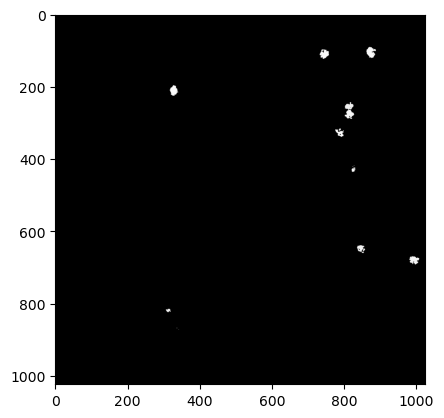

In [20]:
a = dataset["masks"]["ribosome"][300].toarray() 
plt.imshow(a, cmap="gray")

In [44]:
dataset["bboxes"].keys()

dict_keys(['ribosome', 'mitochondria', 'nucleus', 'endoplasmic_reticulum_or_Golgi', 'microtubule', 'membrane', 'nuclear_pore', 'Monolamellar_membrane_vesicle_with_contents'])

In [ ]:
dataset["mapclass"] = {'ribosome': 0,
 'mitochondria_memb': 1,
 'nucleus': 2,
 'endoplasmic_reticulum_or_Golgi': 3}

{'ribosome': 0,
 'mitochondria': 1,
 'nucleus': 2,
 'endoplasmic_reticulum_or_Golgi': 3}

In [23]:
required = {"ribosome": 0, "mitochondria": 1, "nucleus": 2, "endoplasmic_reticulum_or_Golgi": 3, "microtubule":4}
df = {"obj":[], "size":[], "pos_x":[], "pos_y":[], "pos_z":[], "label":[]}
for i in os.listdir("/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/amira/sllt0081_9.62Apx.labels/"):
    pos = int(i[i.rfind("labels")+6:])
    for j in os.listdir("/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/amira/sllt0081_9.62Apx.labels/" + i):
        if j.endswith(".mrc"):
            # print(i, j)
            name = j.split(".")[0] 
            if name not in required:
                continue
            t = utils.readTomogram("/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/amira/sllt0081_9.62Apx.labels/" + i + "/" + j)
            labels, cnts = np.unique(t, return_counts=True)
            for k in labels:
                if k == 0:
                    continue
                x, y = np.where(t == k)
                df["obj"].append(name)
                df["size"].append(cnts[labels == k][0])
                df["pos_x"].append(np.mean(x))
                df["pos_y"].append(np.mean(y))
                df["pos_z"].append(pos)
                df["label"].append(k)
df = pd.DataFrame(df)
df

,obj,size,pos_x,pos_y,pos_z,label
0,nucleus,11483,141.947313,469.310807,400,1
1,nucleus,2790,125.074552,592.479570,400,2
2,nucleus,3373,239.336792,527.608657,400,3
3,nucleus,1982,124.891524,592.367810,395,1
4,nucleus,6288,165.613073,451.395674,395,2
...,...,...,...,...,...,...
556,nucleus,17596,206.464026,361.082689,100,5
557,nucleus,2970,241.447138,14.790236,100,6
558,nucleus,3164,261.969975,395.886536,100,7
559,nucleus,3231,339.710616,425.665119,100,8


In [24]:
df["obj"].value_counts()

obj
nucleus    561
Name: count, dtype: int64

In [ ]:
ann["bboxes"]

## test newdataset

In [18]:
import data 
import importlib 
importlib.reload(data)
ds = data.MrcDataset("/data/transformer_project/transforemer_model/train_data/training/newdata/TS_031.pkl", transform=data.getDefaultTransform(), add_classname=True, require_mask=True)

In [ ]:
d = ds[10]
# for i in range()
utils.drawannotation(d["pixel_values"], d["labels"])

masks


/home/feity/cryoem/data.py:859: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target["masks"] = torch.tensor(target["masks"], dtype=torch.bool).view(


ValueError: masks must be of shape (H, W) or (batch_size, H, W)

In [8]:
mask_length = 5
for i in range(-(mask_length//2), mask_length//2 + 1):
    print(i + mask_length // 2)
    print(i, mask_length//2)

0
-2 2
1
-1 2
2
0 2
3
1 2
4
2 2
